In [ ]:
!pip install transformers datasets --quiet
from transformers import pipeline

In [ ]:
!pip install openai PyMuPDF --quiet

In [ ]:
!pip install pytesseract pdf2image transformers datasets


In [ ]:
!pip install tweepy transformers --quiet


In [ ]:
!pip install transformers pandas matplotlib seaborn --quiet

# What is Transformers?

**Transformers** is an open-source library created by Hugging Face.  
It allows the use of pretrained artificial intelligence models for tasks such as:

- Text classification  
- Text generation  
- Machine translation  
- Text summarization  
- Sentiment analysis  
- Image captioning  
- Question answering  

And more…


# What does `pipeline` do?

The `pipeline()` function is a quick and easy way to use an AI model without having to set everything up manually.

Think of `pipeline` as a “smart factory” that:

1️⃣ Detects the task you want to perform  
2️⃣ Downloads the appropriate model from Hugging Face  
3️⃣ Automatically sets it up  
4️⃣ Makes it ready to use with a single line of code


## Sentiment-analysis

In [ ]:
import pandas as pd
import random

# Variables base
ciudades = ["Lima", "Arequipa", "Trujillo", "Cusco", "Piura"]
entidades = ["EsSalud", "Sutran", "Policía Nacional", "Ministerio de Educación"]
canales = ["Presencial", "Web", "Teléfono", "App móvil"]

# Comentarios simulados con tono mixto
comentarios = {
    "EsSalud": [
        "El médico me atendió bien pero tuve que esperar 3 horas.",
        "Excelente atención en la clínica de Miraflores.",
        "Nunca contestan las llamadas, pésimo servicio.",
        "Me dieron cita para dentro de 3 meses, inaceptable.",
        "Todo el proceso fue rápido y claro, muy satisfecho."
    ],
    "Sutran": [
        "Los inspectores fueron muy amables durante la revisión.",
        "No hay presencia en las carreteras cuando más se necesita.",
        "Poca información disponible en la web.",
        "Buen trabajo con los operativos de seguridad.",
        "Los trámites son muy burocráticos, perdí todo el día."
    ],
    "Policía Nacional": [
        "No quisieron tomar mi denuncia.",
        "Fueron rápidos al llegar al lugar del robo.",
        "La atención fue muy mala, parecían no querer ayudar.",
        "Gracias por el patrullaje en mi barrio, me siento más seguro.",
        "Mucho desinterés del personal en la comisaría."
    ],
    "Ministerio de Educación": [
        "Muy buen contenido en la plataforma virtual.",
        "El colegio no tiene acceso a internet y no nos dan solución.",
        "Faltan profesores y nadie responde los reclamos.",
        "Gracias por apoyar a las escuelas rurales.",
        "No hay seguimiento a las clases virtuales, muy desordenado."
    ]
}

# Generar dataset simulado
data = []
for _ in range(50):
    entidad = random.choice(entidades)
    comentario = random.choice(comentarios[entidad])
    fila = {
        "Ciudad": random.choice(ciudades),
        "Entidad": entidad,
        "Canal": random.choice(canales),
        "Comentario": comentario
    }
    data.append(fila)

df_servicios_publicos = pd.DataFrame(data)



In [ ]:
df_servicios_publicos.head()

,Ciudad,Entidad,Canal,Comentario
0,Piura,EsSalud,Teléfono,El médico me atendió bien pero tuve que espera...
1,Cusco,Policía Nacional,Web,Mucho desinterés del personal en la comisaría.
2,Trujillo,Policía Nacional,App móvil,Fueron rápidos al llegar al lugar del robo.
3,Arequipa,Ministerio de Educación,Presencial,El colegio no tiene acceso a internet y no nos...
4,Trujillo,Ministerio de Educación,App móvil,Gracias por apoyar a las escuelas rurales.


In [ ]:
!pip install transformers --quiet
from transformers import pipeline

# Cargar pipeline de sentimiento
sentiment = pipeline("sentiment-analysis")

# Aplicar análisis a los comentarios
df_servicios_publicos["Sentimiento"] = df_servicios_publicos["Comentario"].apply(lambda x: sentiment(x)[0]['label'])
df_servicios_publicos["Confianza"] = df_servicios_publicos["Comentario"].apply(lambda x: sentiment(x)[0]['score'])

# Ver resultados
df_servicios_publicos.head()


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


,Ciudad,Entidad,Canal,Comentario,Sentimiento,Confianza
0,Trujillo,Sutran,Web,Buen trabajo con los operativos de seguridad.,POSITIVE,0.675577
1,Trujillo,Ministerio de Educación,Web,El colegio no tiene acceso a internet y no nos...,NEGATIVE,0.971703
2,Piura,Ministerio de Educación,Teléfono,"No hay seguimiento a las clases virtuales, muy...",NEGATIVE,0.989728
3,Cusco,Policía Nacional,Web,"La atención fue muy mala, parecían no querer a...",NEGATIVE,0.985868
4,Cusco,Policía Nacional,Presencial,"Gracias por el patrullaje en mi barrio, me sie...",NEGATIVE,0.816869


##  Sentiment Analysis on Twitter

In [ ]:
!pip install tweepy

In [ ]:
import tweepy

# Reemplaza 'TU_BEARER_TOKEN' con tu token real
bearer_token = 'AAAAAAAAAAAAAAAAAAAAABjm2AEAAAAAk8lCEMtL05ZN%2B%2BPVhobKI2oL1Yo%3DDrueHn77xBXINQG1HxJFPEpLyJuP15SWFkBImaImXILUmq5Vch'

client = tweepy.Client(bearer_token=bearer_token)

In [ ]:
import pandas as pd

query = 'reforma tributaria Perú -is:retweet lang:es'
tweets = []

# Realiza la búsqueda de tweets recientes
response = client.search_recent_tweets(query=query, tweet_fields=['created_at', 'author_id', 'public_metrics', 'lang'], max_results=100)

# Procesa los tweets obtenidos
for tweet in response.data:
    tweets.append({
        'Fecha': tweet.created_at,
        'Usuario': tweet.author_id,
        'Texto': tweet.text,
        'Likes': tweet.public_metrics['like_count'],
        'Retweets': tweet.public_metrics['retweet_count']
    })

# Crea un DataFrame con los tweets
df_tweets = pd.DataFrame(tweets)
df_tweets.head()


,Fecha,Usuario,Texto,Likes,Retweets
0,2025-06-03 19:42:06+00:00,942316836263211008,@CassioLithuar @brunoAu2 @chrisbustc @MEF_Peru...,0,0
1,2025-06-02 23:11:42+00:00,1489096137302757376,@HeliaMolina_M @GabrielBoric ¿Con Van Klaveren...,0,0
2,2025-05-29 04:55:17+00:00,1619711255459123200,"📌#ConectateConMayra : ""UN GRAN RETROCESO EN LA...",0,0
3,2025-05-28 14:52:39+00:00,1902829650,Reforma tributaria: ¿Reducir el IGV a 15% es l...,1,0


In [ ]:
df_tweets.to_csv("df_tweets2.csv", index=False)

In [ ]:
from transformers import pipeline

# Carga el modelo de análisis de sentimiento
sentiment_analyzer = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')

# Aplica el análisis de sentimiento a los textos de los tweets
df_tweets['Sentimiento'] = df_tweets['Texto'].apply(lambda x: sentiment_analyzer(x)[0]['label'])
df_tweets.head()


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


,Fecha,Usuario,Texto,Likes,Retweets,Sentimiento
0,2025-06-03 19:42:06+00:00,942316836263211008,@CassioLithuar @brunoAu2 @chrisbustc @MEF_Peru...,0,0,4 stars
1,2025-06-02 23:11:42+00:00,1489096137302757376,@HeliaMolina_M @GabrielBoric ¿Con Van Klaveren...,0,0,1 star
2,2025-05-29 04:55:17+00:00,1619711255459123200,"📌#ConectateConMayra : ""UN GRAN RETROCESO EN LA...",0,0,1 star
3,2025-05-28 14:52:39+00:00,1902829650,Reforma tributaria: ¿Reducir el IGV a 15% es l...,1,0,1 star


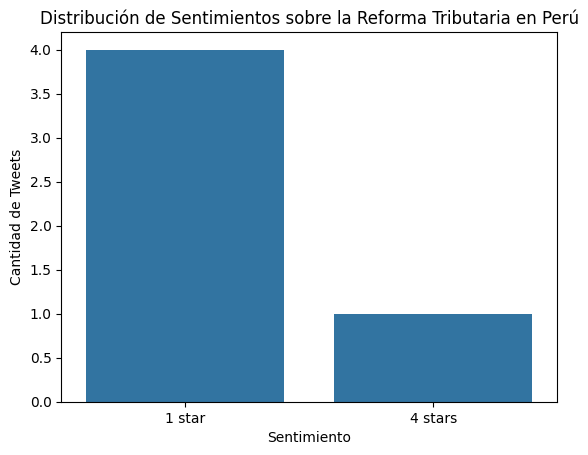

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cuenta la cantidad de cada sentimiento
sentiment_counts = df_tweets['Sentimiento'].value_counts()

# Crea un gráfico de barras
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Distribución de Sentimientos sobre la Reforma Tributaria en Perú')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Tweets')
plt.show()


| Star Rating | Common Interpretation | Sentiment Equivalent    |
|-------------|------------------------|--------------------------|
| 1 star      | Very negative          | 😠 Strong criticism       |
| 2 stars     | Negative               | 😕 Moderate dissatisfaction |
| 3 stars     | Neutral                | 😐 Mixed opinion          |
| 4 stars     | Positive               | 🙂 Satisfaction            |
| 5 stars     | Very positive          | 😄 Very favorable opinion |

In [ ]:
def clasificar_sentimiento(estrella):
    if estrella in ['1 star', '2 stars']:
        return 'Negativo'
    elif estrella == '3 stars':
        return 'Neutral'
    else:
        return 'Positivo'

df_tweets['Sentimiento_simple'] = df_tweets['Sentimiento'].apply(clasificar_sentimiento)


In [ ]:

# Crear nueva columna con la clasificación simplificada
df_tweets['Sentimiento_simple'] = df_tweets['Sentimiento'].apply(clasificar_sentimiento)

# Ver una muestra
df_tweets[['Texto', 'Sentimiento', 'Sentimiento_simple']].head()

,Texto,Sentimiento,Sentimiento_simple
0,@CassioLithuar @brunoAu2 @chrisbustc @MEF_Peru...,4 stars,Positivo
1,@HeliaMolina_M @GabrielBoric ¿Con Van Klaveren...,1 star,Negativo
2,"📌#ConectateConMayra : ""UN GRAN RETROCESO EN LA...",1 star,Negativo
3,Reforma tributaria: ¿Reducir el IGV a 15% es l...,1 star,Negativo


In [ ]:
df_tweets

,Fecha,Usuario,Texto,Likes,Retweets,Sentimiento,Sentimiento_simple
0,2025-06-03 19:42:06+00:00,942316836263211008,@CassioLithuar @brunoAu2 @chrisbustc @MEF_Peru...,0,0,4 stars,Positivo
1,2025-06-02 23:11:42+00:00,1489096137302757376,@HeliaMolina_M @GabrielBoric ¿Con Van Klaveren...,0,0,1 star,Negativo
2,2025-05-29 04:55:17+00:00,1619711255459123200,"📌#ConectateConMayra : ""UN GRAN RETROCESO EN LA...",0,0,1 star,Negativo
3,2025-05-28 14:52:39+00:00,1902829650,Reforma tributaria: ¿Reducir el IGV a 15% es l...,1,0,1 star,Negativo


In [ ]:
df.to_csv("df_tweets.csv", index=False)

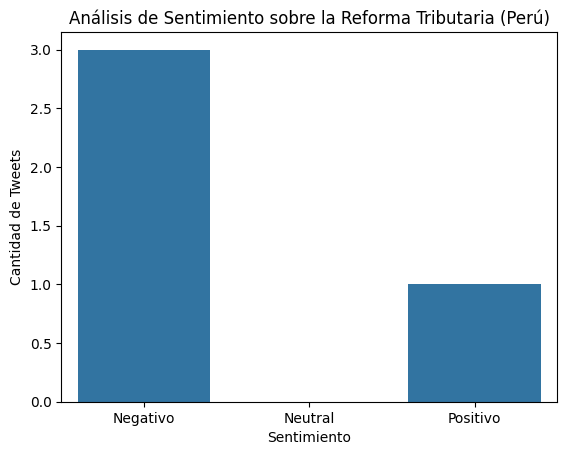

In [ ]:
# Visualizar la cantidad de tweets por sentimiento simple
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_tweets, x='Sentimiento_simple', order=['Negativo', 'Neutral', 'Positivo'])
plt.title('Análisis de Sentimiento sobre la Reforma Tributaria (Perú)')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Tweets')
plt.show()


## zero-shot-classification

Zero-shot classification es una técnica de inteligencia artificial que permite a un modelo clasificar un texto (o imagen) en categorías sin haber sido entrenado específicamente en esas categorías.

You have a text:  
**"Congress passed a new tax law."**

You provide candidate labels:  
`["politics", "sports", "economy", "technology"]`

The model predicts:

- **politics** → 98%  
- **economy** → 89%  
- **sports** → 2%  
- **technology** → 1%


In [ ]:
from transformers import pipeline

# Cargamos el modelo de clasificación zero-shot
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Tweet complejo realista
texto = ("Cambiar el sistema de pensiones a cuentas individuales suena bien en papel, "
         "pero ¿qué pasa con quienes no tienen trabajo formal o ingresos constantes? "
         "Otra vez el Estado se lava las manos y la clase media termina pagando los platos rotos. "
         "#ReformaPrevisional")

# Etiquetas detalladas
etiquetas = [
    "Apoyo técnico informado",
    "Crítica ideológica",
    "Sarcasmo político",
    "Miedo o incertidumbre",
    "Neutral / comentario analítico",
    "Desinformación",
    "Protesta emocional"
]

# Clasificación
resultado = classifier(texto, candidate_labels=etiquetas)

# Mostrar resultado
for label, score in zip(resultado['labels'], resultado['scores']):
    print(f"{label}: {score:.2%}")


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


Miedo o incertidumbre: 38.94%
Apoyo técnico informado: 19.32%
Protesta emocional: 10.70%
Desinformación: 10.16%
Crítica ideológica: 9.28%
Sarcasmo político: 7.99%
Neutral / comentario analítico: 3.62%


In [ ]:
# 1. INSTALACIÓN DE LIBRERÍAS

from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()


In [ ]:
# 2. DEFINIMOS LA LISTA DE COMENTARIOS SIMULADOS (puedes cargar desde un CSV también)
comentarios = [
    "Me parece justa la reforma, los que más ganan deben aportar más.",
    "Otra reforma improvisada del gobierno, solo buscan recaudar sin pensar en el pueblo.",
    "Jajaja ahora dicen que esto es por nuestro bien, qué risa.",
    "No entiendo bien cómo me afectará, deberían explicarlo mejor.",
    "Los empresarios siempre se quejan cuando les toca pagar más impuestos.",
    "Este tipo de cambios generan miedo, ¿y si pierdo mis beneficios?",
    "No es la mejor solución, pero algo había que hacer.",
    "Típico del gobierno: tapar huecos fiscales sin un plan serio.",
    "Yo apoyo la reforma si eso mejora la salud y educación pública.",
    "No es claro si esto impactará a las microempresas, falta detalle."
]

df = pd.DataFrame(comentarios, columns=["Comentario"])
df.head()


,Comentario
0,"Me parece justa la reforma, los que más ganan ..."
1,"Otra reforma improvisada del gobierno, solo bu..."
2,Jajaja ahora dicen que esto es por nuestro bie...
3,"No entiendo bien cómo me afectará, deberían ex..."
4,Los empresarios siempre se quejan cuando les t...


In [ ]:
# 3. CONFIGURAMOS EL MODELO DE CLASIFICACIÓN ZERO-SHOT
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

etiquetas = [
    "Apoyo técnico informado",
    "Crítica ideológica",
    "Sarcasmo político",
    "Miedo o incertidumbre",
    "Neutral / comentario analítico",
    "Desinformación",
    "Protesta emocional"
]


Device set to use cpu


In [ ]:
# 4. APLICAMOS CLASIFICACIÓN A CADA COMENTARIO
def clasificar_narrativa(texto):
    resultado = classifier(texto, candidate_labels=etiquetas)
    return resultado['labels'][0]  # devuelve la etiqueta más probable

df['Narrativa'] = df['Comentario'].progress_apply(clasificar_narrativa)
df.head()


100%|██████████| 10/10 [01:01<00:00,  6.15s/it]


,Comentario,Narrativa
0,"Me parece justa la reforma, los que más ganan ...",Neutral / comentario analítico
1,"Otra reforma improvisada del gobierno, solo bu...",Neutral / comentario analítico
2,Jajaja ahora dicen que esto es por nuestro bie...,Neutral / comentario analítico
3,"No entiendo bien cómo me afectará, deberían ex...",Miedo o incertidumbre
4,Los empresarios siempre se quejan cuando les t...,Miedo o incertidumbre


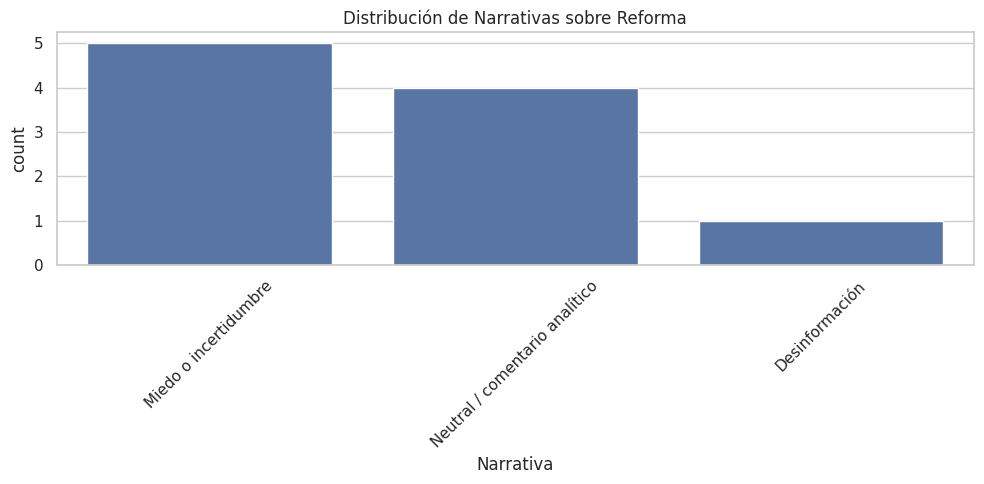

In [ ]:
# 5. VISUALIZACIÓN DE RESULTADOS
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Narrativa", order=df['Narrativa'].value_counts().index)
plt.title("Distribución de Narrativas sobre Reforma")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
df.to_csv("narrativas_clasificadas.csv", index=False)

## Named Entity Recognition (NER)

## 🤖 Why is it useful?

It automates the extraction of key data from large volumes of text without human intervention.

## 🌍 Where is it used?

**Public Sector**: contract analysis, transparency, media monitoring.

**Private Sector**: financial analysis, compliance, data extraction from reports or emails.


In [ ]:

from transformers import pipeline

ner = pipeline("ner", model="dslim/bert-base-NER", grouped_entities=True)



config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/token_classification.py:170: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(


In [ ]:
texto_contrato = """
El 5 de abril de 2023, el Ministerio de Transporte firmó un contrato con Constructora Andes S.A.
por un valor de 15 millones de dólares para la reparación de la Ruta Nacional 40.
"""

resultados = ner(texto_contrato)
for entidad in resultados:
    print(entidad)


{'entity_group': 'ORG', 'score': np.float32(0.56447595), 'word': 'El', 'start': 1, 'end': 3}
{'entity_group': 'ORG', 'score': np.float32(0.9005602), 'word': 'Ministerio de Transporte', 'start': 27, 'end': 51}
{'entity_group': 'ORG', 'score': np.float32(0.72702456), 'word': 'Const', 'start': 74, 'end': 79}
{'entity_group': 'ORG', 'score': np.float32(0.73661083), 'word': '##ctora Andes S. A', 'start': 81, 'end': 96}
{'entity_group': 'ORG', 'score': np.float32(0.8866789), 'word': 'de la Ruta Nacional', 'start': 157, 'end': 176}


In [ ]:
noticia = """
Apple Inc. anunció el miércoles una inversión de 1.000 millones de dólares en India para expandir su cadena de suministro.
El anuncio fue realizado por Tim Cook durante su visita a Nueva Delhi.
"""

resultados = ner(noticia)
for entidad in resultados:
    print(entidad)


{'entity_group': 'ORG', 'score': np.float32(0.99945974), 'word': 'Apple Inc', 'start': 1, 'end': 10}
{'entity_group': 'LOC', 'score': np.float32(0.9993734), 'word': 'India', 'start': 79, 'end': 84}
{'entity_group': 'PER', 'score': np.float32(0.99704003), 'word': 'Tim Cook', 'start': 154, 'end': 162}
{'entity_group': 'LOC', 'score': np.float32(0.86600477), 'word': 'Nueva Delhi', 'start': 183, 'end': 194}


Nota:
El modelo dslim/bert-base-NER agrupa entidades con etiquetas como: B-PER, I-PER, etc., pero cuando usas grouped_entities=True, te las entrega ya agrupadas por tipo (PER, ORG, etc.).

Si necesitas tipos más específicos como LAW, MONEY, DATE, es recomendable usar un modelo basado en OntoNotes, SpaCy o afinar uno propio.

> **Note:** The `dslim/bert-base-NER` model groups entities using tags like `B-PER`, `I-PER`, etc. However, when you use `grouped_entities=True`, it returns them already grouped by type (e.g., `PER`, `ORG`, etc.).

If you need more specific entity types such as `LAW`, `MONEY`, or `DATE`, it's recommended to use a model based on OntoNotes, SpaCy, or to fine-tune your own.


| Entity Group | Meaning                             | Example                                      | Public Sector                         | Private Sector                          |
| ------------ | ----------------------------------- | -------------------------------------------- | ------------------------------------- | ---------------------------------------- |
| `PER`        | Person                              | "Angela Merkel", "Tim Cook"                  | Contract signatories, politicians     | Executives, clients                      |
| `ORG`        | Organization                        | "Ministry of Health", "Google Inc."          | Contracting entities, NGOs            | Companies, strategic partners            |
| `LOC`        | Location (general)                  | "Latin America", "Europe"                    | Areas of operation                    | Regional markets                         |
| `MISC`       | Miscellaneous (events, products...) | "COVID-19", "Champions League", "iPhone 15"  | Public programs, events               | Brands, products                         |
| `DATE`*      | Date                                | "April 5, 2023", "today"                     | Signature dates, execution timelines  | Investment dates, milestones             |
| `MONEY`*     | Amount of money                     | "$1 billion", "15 million euros"             | Budgets, contracted amounts           | Investments, revenues, payments          |
| `GPE`*       | Geopolitical entity (country/city)  | "Colombia", "New Delhi"                      | Headquarters, target regions          | Market locations, branch offices         |


In [ ]:
import fitz  # PyMuPDF
from getpass import getpass
from google.colab import files

In [ ]:
# Pass 3: Load PFF TICKET
print("📎 Load your ticket in PDF")
uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

📎 Load your ticket in PDF


Saving PDF-BOLETAEB01-6220609367963[1].pdf to PDF-BOLETAEB01-6220609367963[1].pdf


In [ ]:
def extraer_texto_pdf(ruta_pdf):
    doc = fitz.open(ruta_pdf)
    texto = ""
    for pagina in doc:
        texto += pagina.get_text()
    doc.close()
    return texto

boleta_texto = extraer_texto_pdf(pdf_path)
boleta_texto

' \n \nGRUPO CEU \nGRUPO CEU SOCIEDAD ANONIMA CERRADA \nCAL. LAS MAGNOLIAS MZA. B LOTE. 8  \nVILLA MARIA DEL TRIUNFO - LIMA - LIMA \nBOLETA DE VENTA ELECTRONICA\nRUC: 20609367963 \nEB01-62 \nFecha de Vencimiento\n:  \nFecha de Emisión\n: 29/01/2023 \nSeñor(es)\n: PAUL ANDRES MELO RAMOS \nDNI \n: 72299843 \nTipo de Moneda\n: SOLES \nObservación\n:  \nCantidad\nUnidad\nMedida\nCódigo\nDescripción\nValor Unitario(*)\nDescuento(*)\nImporte de Venta(**)\nICBPER\n1.00\nUNIDAD\nPE-FA-\n2023\nPROGRAMA DE\nESPECIALIZACION EN\nFINANZAS AVANZADAS\n- DC-MB\n169.49\n0.00\n199.9982\n0.00\nOtros Cargos :\nS/ 0.00 \nOtros Tributos :\nS/0.00 \nICBPER :\nS/ 0.00 \nImporte Total :\nS/200.00 \nSON: DOSCIENTOS Y 00/100 SOLES\n(*) Sin impuestos.\n(**) Incluye impuestos, de ser Op. Gravada.\n \n \n \n \nOp. Gravada :\nS/ 169.49 \nOp. Exonerada :\nS/ 0.00 \nOp. Inafecta :\nS/ 0.00 \nISC :\nS/ 0.00 \nIGV :\nS/ 30.51 \nICBPER :\nS/ 0.00 \nOtros Cargos :\nS/ 0.00 \nOtros Tributos :\nS/ 0.00 \nMonto de Redondeo :

In [ ]:
from transformers import pipeline

# Paso 1: Crear pipeline NER
ner = pipeline("ner", model="dslim/bert-base-NER", grouped_entities=True)

# Paso 2: Aplicar NER sobre la boleta
entidades = ner(boleta_texto)

# Paso 3: Mostrar entidades reconocidas (solo por curiosidad, pocas serán útiles)
for e in entidades:
    print(e)

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


{'entity_group': 'ORG', 'score': np.float32(0.71931976), 'word': 'GR', 'start': 4, 'end': 6}
{'entity_group': 'ORG', 'score': np.float32(0.47876048), 'word': 'CER', 'start': 42, 'end': 45}
{'entity_group': 'ORG', 'score': np.float32(0.73839843), 'word': '##OL', 'start': 64, 'end': 66}
{'entity_group': 'ORG', 'score': np.float32(0.6105898), 'word': 'VI', 'start': 87, 'end': 89}
{'entity_group': 'ORG', 'score': np.float32(0.90327466), 'word': 'MARI', 'start': 93, 'end': 97}
{'entity_group': 'ORG', 'score': np.float32(0.78306806), 'word': 'L', 'start': 113, 'end': 114}
{'entity_group': 'ORG', 'score': np.float32(0.72951734), 'word': '##A', 'start': 116, 'end': 117}
{'entity_group': 'ORG', 'score': np.float32(0.9013155), 'word': 'LIMA BOLETA DE VENTA E', 'start': 120, 'end': 143}
{'entity_group': 'ORG', 'score': np.float32(0.7867691), 'word': '##CTRONICA', 'start': 145, 'end': 153}
{'entity_group': 'ORG', 'score': np.float32(0.83409154), 'word': 'Fecha de V', 'start': 181, 'end': 191}
{'en

This model:

- Is trained on general English (not Spanish).
- Only identifies entities such as `PER`, `ORG`, `LOC`, and `MISC`.

| Model                          | Dataset Used   | Ideal For                           |
|-------------------------------|----------------|-------------------------------------|
| `donut-base-finetuned-docvqa` | DocVQA         | Forms, reports, documents           |
| `donut-base-finetuned-cord-v2`| CORD           | Receipts, invoices, tickets         |
| `donut-base` (no fine-tuning) | None (base)    | Custom training                     |


##  Text Classification

1. 📦 **Dataset:** `billsum` or `lex_glue`

- **billsum**: Summaries of U.S. congressional bills.  
  Useful fields: `text`, `summary`  
  Great for hands-on examples related to legislative topics.

- **lex_glue**: Legal tasks, includes multiple subtasks (e.g., topic classification of court cases).  

For this class, I recommend using `billsum` due to its clarity and focused thematic orientation.


In [ ]:
!pip install datasets transformers scikit-learn


In [ ]:
!pip install -U datasets huggingface_hub fsspec


  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)


In [ ]:
from datasets import load_dataset

dataset = load_dataset("lex_glue", "eurlex", split="train[:1000]")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/34.1k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/55000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
print(dataset[0])

{'text': 'COUNCIL DECISION\nof 7 June 2005\nabrogating Decision 2005/136/EC on the existence of an excessive deficit in the Netherlands\n(2005/729/EC)\nTHE COUNCIL OF THE EUROPEAN UNION,\nHaving regard to the Treaty establishing the European Community, and in particular Article 104(12) thereof,\nHaving regard to the recommendation from the Commission,\nWhereas:\n(1)\nBy Decision 2005/136/EC (1) following a recommendation from the Commission in accordance with Article 104(6) of the Treaty, the Council decided that an excessive deficit existed in the Netherlands.\n(2)\nIn accordance with Article 104(7) of the Treaty, the Council made a Recommendation on 2 June 2004 addressed to the Netherlands with a view to bringing the excessive deficit situation to an end. This Recommendation, in conjunction with Article 3(4) of Council Regulation (EC) No 1467/97 of 7 July 1997 on speeding up and clarifying the implementation of the excessive deficit procedure (2), established a deadline of 2005 at th

## blip-image-captioning-base

**BLIP (Bootstrapping Language-Image Pretraining)** is an artificial intelligence model developed by Salesforce that generates automatic image descriptions in natural language.


In [ ]:
import requests
import pandas as pd
from transformers import pipeline

# Paso 1: Descargar datos desde la API
url = "https://datasets-server.huggingface.co/rows?dataset=huggingface%2Fdocumentation-images&config=default&split=train&offset=0&length=100"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    rows = data['rows']
    print(f"✅ Se recuperaron {len(rows)} documentos.\n")
else:
    print("❌ Error al acceder al dataset.")
    rows = []

# Paso 2: Inspeccionar las entradas
for i, row in enumerate(rows[:5]):
    print(f"🔹 Entrada {i+1}")
    print(row['row'].keys())  # Mostrar las claves disponibles en la entrada
    print(row['row'])
    print("-" * 80)


✅ Se recuperaron 25 documentos.

🔹 Entrada 1
dict_keys(['image', 'label'])
{'image': {'src': 'https://datasets-server.huggingface.co/cached-assets/huggingface/documentation-images/--/2d82e34723ce614399e6ae855b639bd2138da8d5/--/default/train/0/image/image.jpg?Expires=1749048513&Signature=L9LcwkIcTTNKUUzvYp3RaqV4-DyfJ7SYVPKq3JeR4Kx-yyPqAFWmVxfv28HBz2qYwHyc0q5C3E4y1O3GnNPTfow5kHO1SOBCLfQawmyZJ-bX3g1V-V0165lHESNztEzBJdZaxYAXS~ORO34FF0pNMpWrpLrGUVt6Hb0iGHhmItldf5TuzfPeowQ~3S~qkGOGvtM0muodZmbFm2AaZfuz6hsSipZg5xBP6XEq2e~KCeoHQ8mqPjkoOKb9~2unmAmf~v9-SdRe6WRZIboBeDMOtwGu9Bk~Jw~t3uGHzFPI04roojhUsx05fhnzQMLYxkHdSr6GOkYzWxklMjj14g1q9g__&Key-Pair-Id=K3EI6M078Z3AC3', 'height': 512, 'width': 512}, 'label': 4}
--------------------------------------------------------------------------------
🔹 Entrada 2
dict_keys(['image', 'label'])
{'image': {'src': 'https://datasets-server.huggingface.co/cached-assets/huggingface/documentation-images/--/2d82e34723ce614399e6ae855b639bd2138da8d5/--/default/train/1/image

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from transformers import BlipProcessor, BlipForConditionalGeneration

# Cargar el dataset
dataset = load_dataset("huggingface/documentation-images", split="train")

# Visualizar las primeras 5 imágenes
for i in range(5):
    image = dataset[i]['image']
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Imagen {i+1}")
    plt.show()


ValueError: Invalid pattern: '**' can only be an entire path component

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

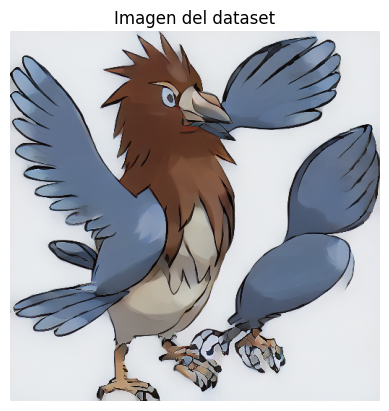

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

📝 Caption generado: a bird with its wings spread out


In [ ]:
from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration
import matplotlib.pyplot as plt

# Paso 1: Cargar el dataset directamente desde Hugging Face
dataset = load_dataset("huggingface/documentation-images", split="train")

# Tomar la primera imagen
image = dataset[0]["image"]

# Paso 2: Mostrar la imagen
plt.imshow(image)
plt.axis('off')
plt.title("Imagen del dataset")
plt.show()

# Paso 3: Cargar el modelo BLIP
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Paso 4: Generar caption
inputs = processor(image, return_tensors="pt")
out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)

# Paso 5: Mostrar resultado
print("📝 Caption generado:", caption)


In [ ]:
from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration
import pandas as pd

# Cargar dataset y modelo
dataset = load_dataset("huggingface/documentation-images", split="train[:10]")  # Usa más si quieres
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Generar captions en lote
captions = []
for i, entry in enumerate(dataset):
    image = entry["image"]
    inputs = processor(image, return_tensors="pt")
    output = model.generate(**inputs)
    caption = processor.decode(output[0], skip_special_tokens=True)
    captions.append({"Index": i, "Caption": caption})

# Mostrar resultados en tabla
df_captions = pd.DataFrame(captions)
df_captions.head()


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

,Index,Caption
0,0,a bird with its wings spread out
1,1,a bird with a long beak and orange beak
2,2,a bird with its wings spread out
3,3,a bird with a red beak and blue tail
4,4,a diagram of the process


## GeoAI

GeoAI is an open-source tool based on pretrained models and datasets available on Hugging Face, designed to automatically detect buildings and other structures in aerial or satellite images.


## Building Footprint Extraction for the USA

GeoAI (Geospatial Artificial Intelligence) is a technology that combines artificial intelligence (AI), geospatial data (such as satellite imagery), and geographic analysis to automate tasks related to maps, terrain, infrastructure, cities, and the environment.


In [ ]:
 %pip install geoai-py

In [ ]:
import geoai

Se descargan una imagen aérea (raster) y un archivo vectorial (GeoJSON) que contiene las huellas de edificaciones correspondientes.

In [ ]:
raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train.tif"
)
vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train_buildings.geojson"

In [ ]:
raster_path = geoai.download_file(raster_url)

naip_train.tif: 100%|██████████| 12.1M/12.1M [00:00<00:00, 16.6MB/s]


In [ ]:
vector_path = geoai.download_file(vector_url)

naip_train_buildings.geojson: 100%|██████████| 456k/456k [00:00<00:00, 7.29MB/s]


Se crea una instancia del extractor de huellas de edificaciones utilizando un modelo preentrenado.

In [ ]:
extractor = geoai.BuildingFootprintExtractor()

Model path not specified, downloading from Hugging Face...


building_footprints_usa.pth:   0%|          | 0.00/176M [00:00<?, ?B/s]

Model downloaded to: /root/.cache/huggingface/hub/models--giswqs--geoai/snapshots/75788bf6253e967a91b9576b1620949a3b939820/building_footprints_usa.pth
Model loaded successfully


Extract building footprints

Se genera una máscara raster que indica las áreas donde se encuentran las edificaciones.

In [ ]:
mask_path = extractor.save_masks_as_geotiff(
    raster_path=raster_path,
    output_path="building_masks.tif",
    confidence_threshold=0.5,
    mask_threshold=0.5,
)

Processing masks with parameters:
- Confidence threshold: 0.5
- Chip size: (512, 512)
- Mask threshold: 0.5
Dataset initialized with 3 rows and 7 columns of chips
Image dimensions: 2503 x 1126 pixels
Chip size: 512 x 512 pixels
Overlap: 25.0% (stride_x=384, stride_y=384)
CRS: EPSG:26911
Processing raster with 6 batches


100%|██████████| 6/6 [03:57<00:00, 39.56s/it]

Object masks saved to building_masks.tif


Luego, se convierte esta máscara en un archivo vectorial (GeoJSON).

In [ ]:
gdf = extractor.masks_to_vector(
    mask_path=mask_path,
    output_path="building_masks.geojson",
    simplify_tolerance=1.0,
)

Converting mask to GeoJSON with parameters:
- Mask threshold: 0.5
- Min object area: 100
- Max object area: None
- Simplify tolerance: 1.0
- NMS IoU threshold: 0.5
- Regularize objects: True
- Angle threshold: 15° from 90°
- Rectangularity threshold: 70.0%
Mask dimensions: (1126, 2503)
Mask value range: 0 to 255
Found 696 potential objects


100%|██████████| 696/696 [00:03<00:00, 222.56it/s]


Created 664 valid polygons
Object count after NMS filtering: 664
Regularizing 664 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 30.0% of angles
- Min rectangularity: 70.0% of bounding box area


100%|██████████| 664/664 [00:00<00:00, 771.38it/s]


Regularization completed:
- Total objects: 664
- Rectangular objects: 660 (99.4%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 4 (0.6%)
Saved 664 objects to building_masks.geojson


Se procesa la imagen raster para extraer directamente las huellas de edificaciones en formato vectorial.

In [ ]:
output_path = "naip_buildings.geojson"
gdf = extractor.process_raster(
    raster_path,
    output_path="buildings.geojson",
    batch_size=4,
    confidence_threshold=0.5,
    overlap=0.25,
    nms_iou_threshold=0.5,
    min_object_area=100,
    max_object_area=None,
    mask_threshold=0.5,
    simplify_tolerance=1.0,
)

Processing with parameters:
- Confidence threshold: 0.5
- Tile overlap: 0.25
- Chip size: (512, 512)
- NMS IoU threshold: 0.5
- Mask threshold: 0.5
- Min object area: 100
- Max object area: None
- Simplify tolerance: 1.0
- Filter edge objects: True
- Edge buffer size: 20 pixels
Dataset initialized with 3 rows and 7 columns of chips
Image dimensions: 2503 x 1126 pixels
Chip size: 512 x 512 pixels
Overlap: 25.0% (stride_x=384, stride_y=384)
CRS: EPSG:26911
Processing raster with 6 batches


100%|██████████| 6/6 [02:59<00:00, 29.86s/it]


Objects before filtering: 749
Objects after filtering: 749
Saved 749 objects to buildings.geojson


Se aplica una regularización para mejorar la geometría de las huellas detectadas, ajustándolas a formas más ortogonales y rectangulares.

In [ ]:
gdf_regularized = extractor.regularize_buildings(
    gdf=gdf,
    min_area=100,
    angle_threshold=15,
    orthogonality_threshold=0.3,
    rectangularity_threshold=0.7,
)

Regularizing 749 objects...
- Angle threshold: 15° from 90°
- Min orthogonality: 30.0% of angles
- Min rectangularity: 70.0% of bounding box area


100%|██████████| 749/749 [00:00<00:00, 818.11it/s]

Regularization completed:
- Total objects: 749
- Rectangular objects: 696 (92.9%)
- Other regularized objects: 0 (0.0%)
- Unmodified objects: 53 (7.1%)


Visualize building footprints

In [ ]:
gdf.head()

,geometry,confidence,class
548,"POLYGON ((455272.2 5277763.2, 455271 5277762, ...",0.999945,1
1234,"POLYGON ((455984.4 5277643.8, 455983.8 5277643...",0.999941,1
888,"POLYGON ((456074.4 5277719.4, 456073.2 5277718...",0.999941,1
549,"POLYGON ((455243.4 5277855, 455242.8 5277854.4...",0.999938,1
438,"POLYGON ((454989 5277799.2, 454988.4 5277798.6...",0.999931,1


In [ ]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles="Satellite"
)

In [ ]:
geoai.view_vector_interactive(
    gdf, column="confidence", layer_name="Building", tiles=raster_url
)

In [ ]:
geoai.view_vector_interactive(
    gdf_regularized, column="confidence", layer_name="Building", tiles=raster_url
)

Using confidence values (range: 0.57 - 1.00)
Visualization saved to naip_buildings.png
Sample visualization saved to naip_buildings_sample.png


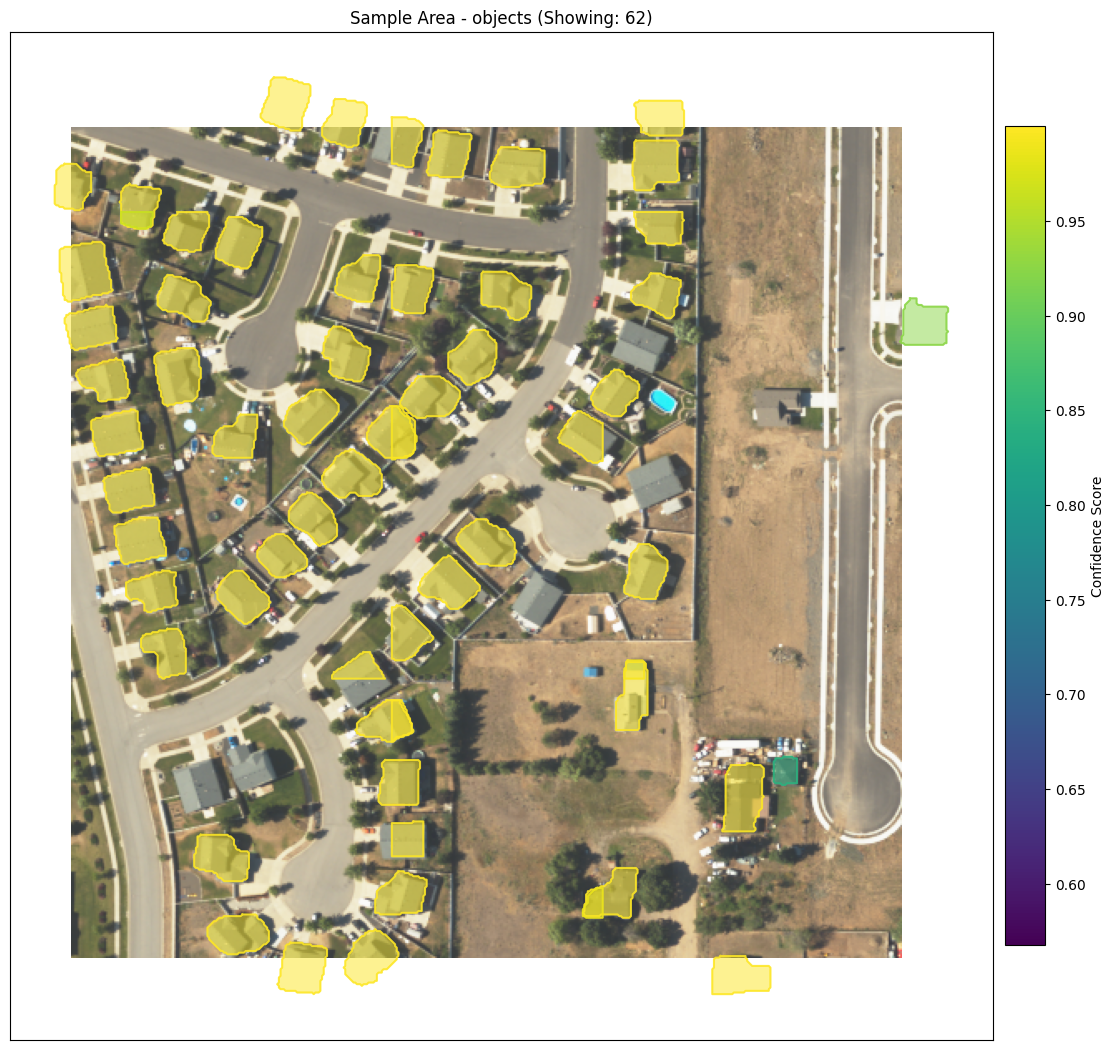

In [ ]:
extractor.visualize_results(raster_path, gdf, output_path="naip_buildings.png")

Using confidence values (range: 0.57 - 1.00)
Visualization saved to naip_buildings_regularized.png
Sample visualization saved to naip_buildings_regularized_sample.png


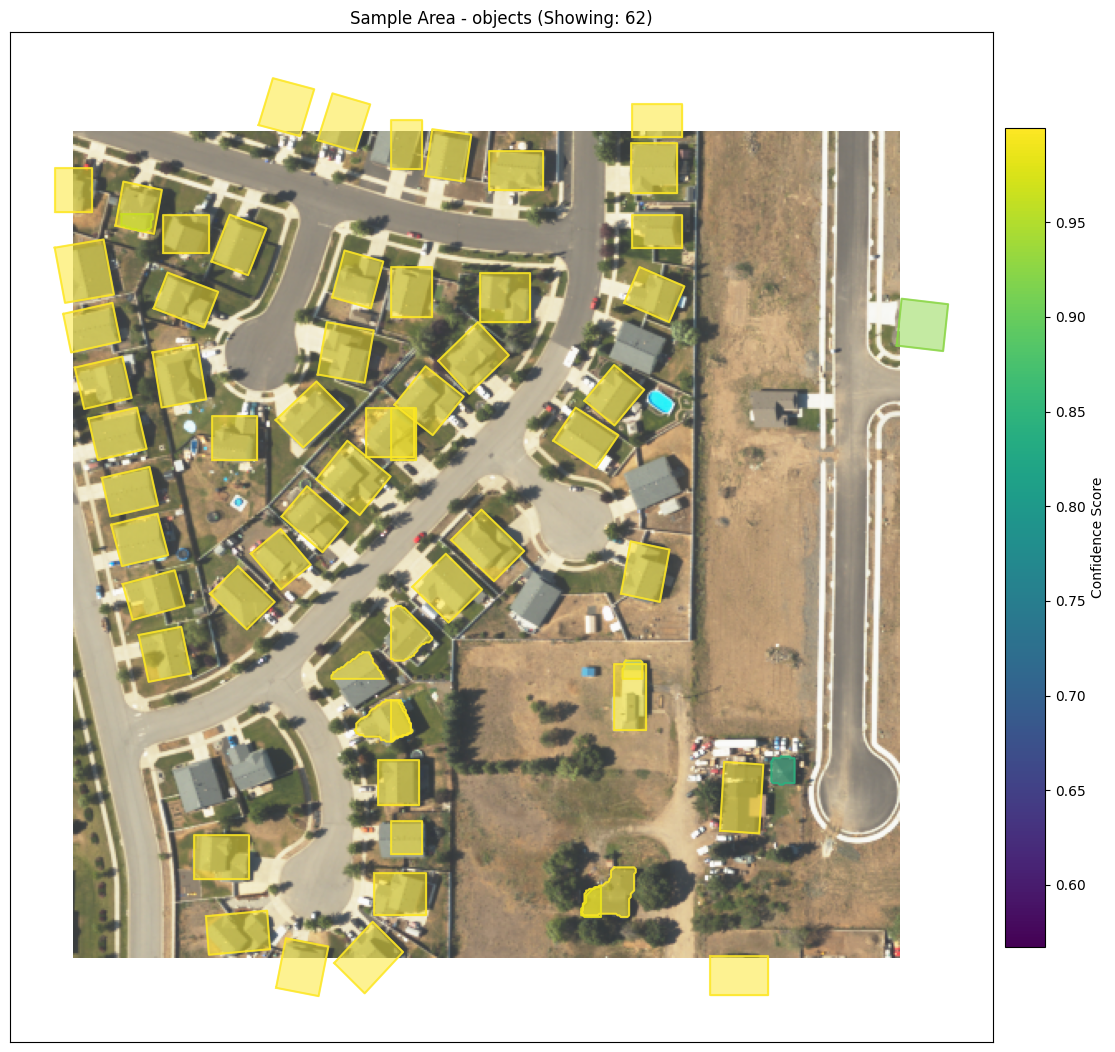

In [ ]:
extractor.visualize_results(
    raster_path, gdf_regularized, output_path="naip_buildings_regularized.png"
)

This workflow allows you to:

- Automatically detect buildings in aerial images.
- Obtain building footprints in vector format for analysis in Geographic Information Systems (GIS).
- Improve the geometric quality of the footprints through regularization.
- Visualize and export the results for use in various applications such as urban planning, infrastructure analysis, and environmental studies.
